In [5]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import time
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC


In [165]:
SEARCH_QUERY = "sony wireless over-ear noise cancelling headphones"
NUM_PAGES = 7
OUTPUT_FILE = "amazon_wireless_headphones.csv"

def clean_rating(text):
    if not text:
        return None
    match = re.search(r"\d+\.\d+", text)
    return float(match.group()) if match else None

options = Options()
options.add_argument("--headless=new")
options.add_argument("--window-size=1920,1080")

driver = webdriver.Chrome(options=options)
wait = WebDriverWait(driver, 15)

rows = []

try:
    for page in range(1, NUM_PAGES + 1):
        #url = f"https://www.amazon.com/s?k=wireless+headphones&rh=n%3A21514463011%2Cp_123%3A233043%257C264616%257C325772&dc&crid=37RAF0SVWP0ZZ&qid=1776023787&rnid=85457740011&sprefix=%2Caps%2C177&ref=sr_nr_p_123_4&ds=v1%3AaS7xNxv3ETbq0rBMp0a1QOxUuJUGO4XFffw2gLNIQOY"
        url = f"https://www.amazon.com/s?k={SEARCH_QUERY.replace(' ', '+')}&page={page}"
        driver.get(url)

        # print("URL:", driver.current_url)
        # print("TITLE:", driver.title)
        # print("CARDS FOUND:", len(driver.find_elements(By.CSS_SELECTOR, 'div[data-component-type="s-search-result"]')))
        # print(driver.page_source[:1500])

        wait.until(
            EC.presence_of_all_elements_located(
                (By.CSS_SELECTOR, 'div[data-component-type="s-search-result"]')
            )
        )

        time.sleep(2)
        product_cards = driver.find_elements(By.CSS_SELECTOR, 'div[data-component-type="s-search-result"]')

        for card in product_cards:
            title = None
            rating = None
            review_count = None
            price = None
            asin = None

            try:
                asin = card.get_attribute("data-asin")
            except:
                pass

           
            try:
                title = card.find_element(By.CSS_SELECTOR, "h2[aria-label]").get_attribute("aria-label")
            except:
                pass

            if not title:
                h2_tags = card.find_elements(By.CSS_SELECTOR, "h2 span")
                title_parts = []

                for el in h2_tags:
                    text = el.text.strip()
                    if text and text.lower() != "sponsored ad -":
                        title_parts.append(text)

                title = " ".join(title_parts) if title_parts else None

            rating_text = None
            selectors_to_try = [
                "span.a-icon-alt",
                "i span.a-icon-alt",
                '[aria-label*="out of 5 stars"]',
                '[aria-label*="stars"]'
            ]

            for sel in selectors_to_try:
                try:
                    el = card.find_element(By.CSS_SELECTOR, sel)
                    rating_text = el.text.strip() or el.get_attribute("aria-label")
                    if rating_text:
                        break
                except:
                    continue

            rating = clean_rating(rating_text)

            try:
                review_tag = card.find_element(
                    By.CSS_SELECTOR,
                    'span.a-size-mini.puis-normal-weight-text.s-underline-text'
                )
                
                review_text = review_tag.text.strip()

                review_text = review_text.replace("(", "").replace(")", "").lower()

                if "k" in review_text:
                    number = float(review_text.replace("k", ""))
                    review_count = int(number * 1000)
                else:
                    review_count = int(review_text.replace(",", ""))

            except:
                pass

            try:
                whole = card.find_element(By.CSS_SELECTOR, ".a-price-whole").text
                fraction = card.find_element(By.CSS_SELECTOR, ".a-price-fraction").text
                
                price = float(f"{whole}.{fraction}")

            except:
                pass
        

            if title:
                rows.append({
                    "asin": asin,
                    "title": title,
                    "rating": rating,
                    "number_of_reviews": review_count,
                    "price": price,
                    "page": page,
                    "source": "Amazon"
                })

            

        time.sleep(2)

finally:
    driver.quit()

df = pd.DataFrame(rows)
df.to_csv(OUTPUT_FILE, index=False)
print(f"Saved {len(df)} rows to {OUTPUT_FILE}")


Saved 112 rows to amazon_wireless_headphones.csv


In [6]:
df = pd.read_csv("amazon_wireless_headphones.csv")
df.head(10)

,asin,title,rating,number_of_reviews,price,page,source
0,B0BS1QCFHX,WH-CH720N Noise Canceling Wireless Headphones ...,4.4,15000.0,NaN,1,Amazon
1,B0DY8TS92J,WH-CH720N Noise Canceling Wireless Headphones ...,4.4,15000.0,98.0,1,Amazon
2,B09XS7JWHH,"WH-1000XM5 Premium Noise Canceling Headphones,...",4.2,19200.0,248.0,1,Amazon
3,B0BS74M665,WH-CH720N Noise Canceling Wireless Headphones ...,4.4,15000.0,98.0,1,Amazon
4,B0CWVX1GNX,ULT WEAR Over-Ear Noise Canceling Bluetooth He...,4.3,3000.0,NaN,1,Amazon
5,B0BXYCS74H,"WH-1000XM5 Premium Noise Canceling Headphones,...",4.2,19200.0,248.0,1,Amazon
6,B0F3PT1VBL,WH-1000XM6 The Best Noise Canceling Wireless H...,4.3,2600.0,428.0,1,Amazon
7,B0CWVXTK6Z,ULT WEAR Over-Ear Noise Canceling Bluetooth He...,4.3,3000.0,148.0,1,Amazon
8,B0BS1RT9S2,WH-CH520 Wireless Headphones Bluetooth On-Ear ...,4.5,31300.0,38.0,1,Amazon
9,B0CFSCT8GQ,WH-CH720NB Noise Canceling Wireless Bluetooth ...,4.5,1300.0,98.0,1,Amazon


In [7]:
df.shape

(112, 7)

In [8]:
display(pd.DataFrame(df.dtypes.astype(str), columns=['dtype']).reset_index().rename(columns={'index':'column'}))

,column,dtype
0,asin,object
1,title,object
2,rating,float64
3,number_of_reviews,float64
4,price,float64
5,page,int64
6,source,object


Checking whether there are duplicate "asin"s -

In [9]:
total = len(df)
unique_asins = df['asin'].nunique(dropna=True)
dup_mask = df['asin'].duplicated(keep=False)
dup_count = dup_mask.sum()

print(f"Total rows: {total}")
print(f"Unique ASINs (excluding NaN): {unique_asins}")
print(f"Rows involved in duplicates: {dup_count}")

if dup_count:
    dup_summary = df.loc[dup_mask, 'asin'].value_counts()
    display(dup_summary.to_frame(name='count'))
    display(df[dup_mask].sort_values('asin').reset_index(drop=True))
else:
    print("No duplicate ASINs found.")

Total rows: 112
Unique ASINs (excluding NaN): 111
Rows involved in duplicates: 2


,count
asin,
B0DD98WLF6,2


,asin,title,rating,number_of_reviews,price,page,source
0,B0DD98WLF6,Sony WH-1000XM5/L Wireless Industry Leading No...,4.1,53.0,229.99,6,Amazon
1,B0DD98WLF6,Sony WH-1000XM5/L Wireless Industry Leading No...,4.1,53.0,229.99,7,Amazon


In [10]:
# keep only the first occurrence for each asin
prev_count = df.shape[0]
df = df.drop_duplicates(subset="asin", keep="first").reset_index(drop=True)
print(f"Dropped {prev_count - df.shape[0]} duplicate rows; new row count: {df.shape[0]}")

Dropped 1 duplicate rows; new row count: 111


Checking for null values across "title", "price", "rating"

In [11]:
# check nulls for requested columns (handle "Price" vs "price" name)
cols_req = ['title', 'price', 'rating']
cols = []
for c in cols_req:
    if c in df.columns:
        cols.append(c)
    elif c == 'price' and 'Price' in df.columns:
        cols.append('Price')
    else:
        print(f"Column not found: {c!r}")

if not cols:
    raise KeyError("None of the requested columns were found in df.")

total = len(df)
null_counts = df[cols].isnull().sum()
null_percent = (null_counts / total * 100).round(2)

summary = pd.DataFrame({
    'column': cols,
    'null_count': null_counts.values,
    'null_percent': null_percent.values
})
display(summary.set_index('column'))

# show rows with any null among these columns (if any)
if summary['null_count'].sum() > 0:
    display(df[df[cols].isnull().any(axis=1)][cols].reset_index())

,null_count,null_percent
column,,
title,0,0.00
price,10,9.01
rating,5,4.50


,index,title,price,rating
0,0,WH-CH720N Noise Canceling Wireless Headphones ...,NaN,4.4
1,4,ULT WEAR Over-Ear Noise Canceling Bluetooth He...,NaN,4.3
2,16,WH-CH720N Noise Canceling Wireless Headphones ...,NaN,4.4
3,19,Sony WH-CH720N/P Bluetooth Wireless Noise-Canc...,59.99,NaN
4,22,Noise Cancelling Headphones WHCH710N: Wireless...,NaN,4.4
5,26,Sony - WH-CH720N Wireless Noise Canceling Head...,59.99,NaN
6,27,"WH1000XM3 Noise Cancelling Headphones, Wireles...",NaN,4.6
7,41,WH-XB910N EXTRA BASS Noise Cancelling Headphon...,NaN,4.5
8,53,ULT WEAR Wireless Noise Cancelling Over-Ear He...,148.00,NaN
9,56,WH-CH720NL Noise Canceling Wireless Bluetooth ...,NaN,4.5


In [12]:
price_col = 'price' if 'price' in df.columns else ('Price' if 'Price' in df.columns else None)
rating_col = 'rating' if 'rating' in df.columns else ('Rating' if 'Rating' in df.columns else None)
required = ['title', price_col, rating_col]

if None in required:
    missing = [k for k in ['title', 'price/range', 'rating'] if (k == 'title' and 'title' not in df.columns) or (k == 'price/range' and price_col is None) or (k == 'rating' and rating_col is None)]
    raise KeyError(f"Required column(s) missing: {missing}")

prev = len(df)
df = df.dropna(subset=['title', price_col, rating_col]).reset_index(drop=True)
print(f"Dropped {prev - len(df)} rows; new row count: {len(df)}")

Dropped 15 rows; new row count: 96


In [13]:
# find outliers in the price column using IQR and z-score methods
if 'price' in df.columns:
    price_col = 'price'
elif 'Price' in df.columns:
    price_col = 'Price'
else:
    raise KeyError("No price column found (expected 'price' or 'Price')")

s = df[price_col]
s_nonnull = s.dropna()

Q1 = s_nonnull.quantile(0.25)
Q3 = s_nonnull.quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

mean = s_nonnull.mean()
std = s_nonnull.std(ddof=0)  # population std to be stricter
z = (s - mean) / std
z_thresh = 3.0

iqr_mask = s.notna() & ((s < lower_iqr) | (s > upper_iqr))
z_mask = s.notna() & (z.abs() > z_thresh)

outliers = df[iqr_mask | z_mask].copy()
outliers['outlier_iqr'] = iqr_mask.loc[outliers.index]
outliers['outlier_z'] = z_mask.loc[outliers.index]
outliers = outliers.sort_values(by=price_col, ascending=False).reset_index(drop=True)

print(f"Using column: {price_col}")
print(f"IQR range: [{lower_iqr:.2f}, {upper_iqr:.2f}]  (IQR={IQR:.2f})")
print(f"Z-score threshold: ±{z_thresh}")
print(f"Total rows: {len(df)}, non-null prices: {len(s_nonnull)}")
print(f"IQR outliers: {iqr_mask.sum()}, Z outliers: {z_mask.sum()}, Either: {len(outliers)}")

outliers

Using column: price
IQR range: [-238.03, 503.35]  (IQR=185.35)
Z-score threshold: ±3.0
Total rows: 96, non-null prices: 96
IQR outliers: 0, Z outliers: 0, Either: 0


,asin,title,rating,number_of_reviews,price,page,source,outlier_iqr,outlier_z


Therefore currently no outliers have been found in the data

In [14]:
# save cleaned dataframe to new CSV
df.to_csv("amazon_clean.csv", index=False)
print(f"Saved {len(df)} rows to amazon_clean.csv")

Saved 96 rows to amazon_clean.csv


Rows with valid data for correlation: 96
Pearson correlation: 0.0654
Spearman correlation: 0.0289


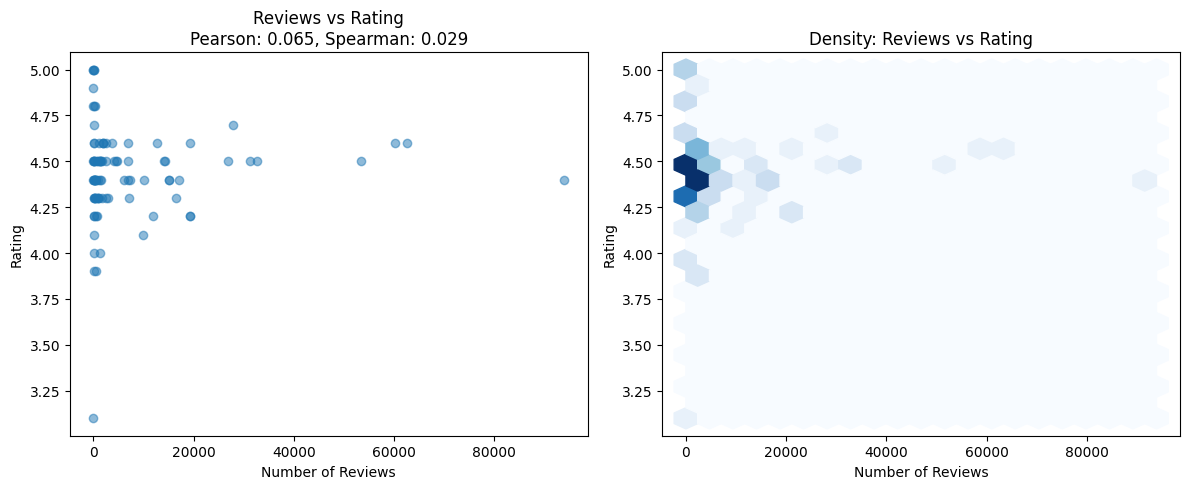

In [15]:
import numpy as np

# Check correlation between number of reviews and rating

# Select only the columns we need and drop any rows with missing values
corr_df = df[['number_of_reviews', 'rating']].dropna()

print(f"Rows with valid data for correlation: {len(corr_df)}")

# Calculate Pearson correlation
pearson_corr = corr_df['number_of_reviews'].corr(corr_df['rating'])
print(f"Pearson correlation: {pearson_corr:.4f}")

# Calculate Spearman correlation (better for non-linear relationships)
spearman_corr = corr_df['number_of_reviews'].corr(corr_df['rating'], method='spearman')
print(f"Spearman correlation: {spearman_corr:.4f}")

# Visualize the relationship
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot
axes[0].scatter(corr_df['number_of_reviews'], corr_df['rating'], alpha=0.5)
axes[0].set_xlabel('Number of Reviews')
axes[0].set_ylabel('Rating')
axes[0].set_title(f'Reviews vs Rating\nPearson: {pearson_corr:.3f}, Spearman: {spearman_corr:.3f}')

# Hexbin plot for density
axes[1].hexbin(corr_df['number_of_reviews'], corr_df['rating'], gridsize=20, cmap='Blues')
axes[1].set_xlabel('Number of Reviews')
axes[1].set_ylabel('Rating')
axes[1].set_title('Density: Reviews vs Rating')

plt.tight_layout()
plt.show()

In [2]:
SEARCH_QUERY = "sony wireless over-ear noise cancelling headphones"
NUM_PAGES = 7
OUTPUT_FILE = "walmart_wireless_headphones.csv"

def clean_rating(text):
    if not text:
        return None
    match = re.search(r"\d+\.\d+", text)
    return float(match.group()) if match else None

options = Options()
options.add_argument("--headless=new")
options.add_argument("--window-size=1920,1080")

driver = webdriver.Chrome(options=options)
wait = WebDriverWait(driver, 15)

rows = []

try:
    for page in range(1, NUM_PAGES + 1):
        url = f"https://www.walmart.com/search?q={SEARCH_QUERY.replace(' ', '+')}&page={page}"
        driver.get(url)

        time.sleep(3)

        product_cards = driver.find_elements(By.CSS_SELECTOR, 'role[group]')

        seen = set()

        for card in product_cards:
            title = None
            rating = None
            review_count = None
            price = None
            data_item_id = None
            url = None

            try:
                url = card.get_attribute("href")
            except:
                pass

            if not url or url in seen:
                continue
            seen.add(url)

            try:
                data_item_id = card.get_attribute("data-item-id")
            except:
                pass

            try:
                title = card.text.strip().split("\n")[0]
            except:
                pass

            if not title:
                try:
                    title = card.get_attribute("aria-label")
                except:
                    pass

            try:
                card_text = card.text

                # PRICE
                price_match = re.search(r"\$\s?(\d+(?:\.\d{2})?)", card_text)
                if price_match:
                    price = float(price_match.group(1))

                # RATING
                rating_match = re.search(r"(\d+\.\d+)\s*out of 5 stars", card_text, re.IGNORECASE)
                if rating_match:
                    rating = float(rating_match.group(1))
                else:
                    rating_match = re.search(r"(\d+\.\d+)", card_text)
                    if rating_match:
                        rating = float(rating_match.group(1))

                # REVIEW COUNT
                review_match = re.search(r"\(?\s*(\d+(?:\.\d+)?k?|\d+)\s*\)?\s*reviews?", card_text, re.IGNORECASE)
                if review_match:
                    review_text = review_match.group(1).lower().replace(",", "").replace("(", "").replace(")", "")
                    if "k" in review_text:
                        review_count = int(float(review_text.replace("k", "")) * 1000)
                    else:
                        review_count = int(review_text)
            except:
                pass

            if title:
                rows.append({
                    "item_id": item_id,
                    "title": title,
                    "rating": rating,
                    "number_of_reviews": review_count,
                    "price": price,
                    "page": page,
                    "source": "Walmart",
                    "url": url
                })

        time.sleep(2)

finally:
    driver.quit()

df = pd.DataFrame(rows)
df.to_csv(OUTPUT_FILE, index=False)
print(f"Saved {len(df)} rows to {OUTPUT_FILE}")

NameError: name 'Options' is not defined